In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- 1. PRÉPARATION DES DONNÉES (Socle Commun) ---
df = pd.read_csv("data/divorces_2000-2015_translated.csv")

# Nettoyage standard (Dates, Revenus, Âges)
def clean_date_century(x):
    if pd.isnull(x): return pd.NaT
    if x.year > 2020: return x - pd.DateOffset(years=100)
    return x

for col in ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce').apply(clean_date_century)

df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])
df['Income_Total'] = df['Monthly_income_partner_man_peso'].fillna(df['Monthly_income_partner_man_peso'].median()) + \
                     df['Monthly_income_partner_woman_peso'].fillna(df['Monthly_income_partner_woman_peso'].median())
df['Num_Children'] = df['Num_Children'].fillna(0)
df = df.dropna(subset=['Marriage_duration', 'Type_of_divorce']) # Nettoyage de base

# --- FONCTION GÉNÉRIQUE POUR LA VALIDATION CROISÉE ---
def run_cv(X, y, description):
    """Lance une validation croisée et affiche les résultats proprement."""
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    # StratifiedKFold garde les proportions de classes (important si déséquilibré)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy') # On utilise l'Accuracy ici

    print(f"\n=== {description} ===")
    print(f"Scores par pli : {scores}")
    print(f"--> MOYENNE : {scores.mean():.2%} (+/- {scores.std():.2%})")
    return scores.mean()

# ==============================================================================
# EXPÉRIENCE A : DURÉE DU MARIAGE (3 Classes) - AVEC ENFANTS (Biaisé)
# ==============================================================================

# 1. Création de la cible (3 classes)
def categorize_duration(years):
    if years < 5: return "Court"
    elif years < 15: return "Moyen"
    else: return "Long"

y_duration = df['Marriage_duration'].apply(categorize_duration)

# 2. Features (AVEC Enfants)
features_biased = ['Age_at_marriage_man', 'Age_diff', 'Income_Total', 'Num_Children'] # Biais ici
X_biased = df[features_biased]

run_cv(X_biased, y_duration, "Exp A : Durée (Avec Enfants - Biaisé)")


# ==============================================================================
# EXPÉRIENCE B : DURÉE DU MARIAGE (3 Classes) - SANS ENFANTS (Honnête)
# ==============================================================================

# 1. Features (SANS Enfants)
features_honest = ['Age_at_marriage_man', 'Age_diff', 'Income_Total'] # Pas d'enfants
X_honest = df[features_honest]

run_cv(X_honest, y_duration, "Exp B : Durée (Sans Enfants - Honnête)")


# ==============================================================================
# EXPÉRIENCE C : TYPE DE DIVORCE (Amiable vs Conflictuel)
# ==============================================================================

# 1. Création de la cible (Type)
le = LabelEncoder()
y_type = le.fit_transform(df['Type_of_divorce']) # 0=Necesario, 1=Voluntario

# 2. Features (Ici on garde les enfants car c'est une cause légitime de conflit)
features_type = ['Age_at_marriage_man', 'Age_diff', 'Income_Total', 'Num_Children', 'Marriage_duration']
X_type = df[features_type]

run_cv(X_type, y_type, "Exp C : Type de Divorce (Amiable vs Conflictuel)")


=== Exp A : Durée (Avec Enfants - Biaisé) ===
Scores par pli : [0.52985075 0.49147122 0.52665245 0.52401281 0.51867663]
--> MOYENNE : 51.81% (+/- 1.38%)

=== Exp B : Durée (Sans Enfants - Honnête) ===
Scores par pli : [0.42963753 0.40618337 0.41577825 0.41088581 0.41408751]
--> MOYENNE : 41.53% (+/- 0.79%)

=== Exp C : Type de Divorce (Amiable vs Conflictuel) ===
Scores par pli : [0.71108742 0.73987207 0.71535181 0.70330843 0.74919957]
--> MOYENNE : 72.38% (+/- 1.76%)


np.float64(0.7237638609817204)

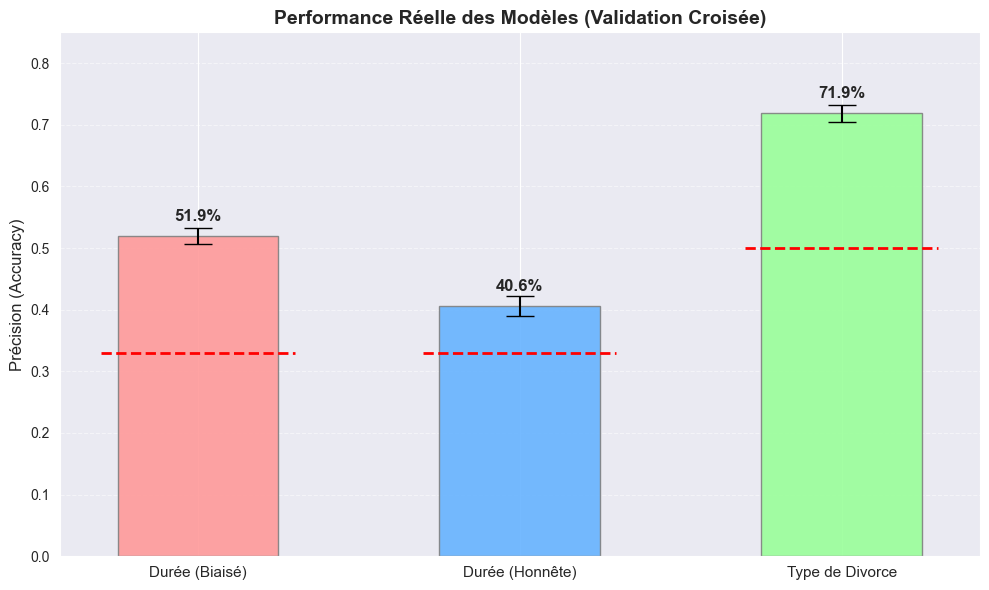

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- 1. CHARGEMENT ET PRÉPARATION (Comme d'habitude) ---
df = pd.read_csv("data/divorces_2000-2015_translated.csv")

def clean_date_century(x):
    if pd.isnull(x): return pd.NaT
    if x.year > 2020: return x - pd.DateOffset(years=100)
    return x

for col in ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce').apply(clean_date_century)

df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])
df['Income_Total'] = df['Monthly_income_partner_man_peso'].fillna(df['Monthly_income_partner_man_peso'].median()) + \
                     df['Monthly_income_partner_woman_peso'].fillna(df['Monthly_income_partner_woman_peso'].median())
df['Num_Children'] = df['Num_Children'].fillna(0)

# Nettoyage de base pour éviter les erreurs
df = df.dropna(subset=['Marriage_duration', 'Type_of_divorce'])

# --- 2. DÉFINITION DES 3 EXPÉRIENCES ---

results_mean = []
results_std = []
baselines = []

# --- EXP A : DURÉE BIAISÉE (Avec Enfants) ---
def categorize_duration(years):
    if years < 5: return "Court"
    elif years < 15: return "Moyen"
    else: return "Long"

y_duration = df['Marriage_duration'].apply(categorize_duration)
X_biased = df[['Age_at_marriage_man', 'Age_diff', 'Income_Total', 'Num_Children']]

clf = RandomForestClassifier(n_estimators=50, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_a = cross_val_score(clf, X_biased, y_duration, cv=cv, scoring='accuracy')

results_mean.append(scores_a.mean())
results_std.append(scores_a.std())
baselines.append(0.33) # Hasard 3 classes

# --- EXP B : DURÉE HONNÊTE (Sans Enfants) ---
X_honest = df[['Age_at_marriage_man', 'Age_diff', 'Income_Total']] # Pas d'enfants

scores_b = cross_val_score(clf, X_honest, y_duration, cv=cv, scoring='accuracy')

results_mean.append(scores_b.mean())
results_std.append(scores_b.std())
baselines.append(0.33)

# --- EXP C : TYPE DE DIVORCE ---
le = LabelEncoder()
y_type = le.fit_transform(df['Type_of_divorce'])
# On filtre les classes trop petites s'il y en a (par sécurité)
valid_indices = df['Type_of_divorce'].map(df['Type_of_divorce'].value_counts()) > 10
X_type = df.loc[valid_indices, ['Age_at_marriage_man', 'Age_diff', 'Income_Total', 'Num_Children', 'Marriage_duration']]
y_type = y_type[valid_indices]

scores_c = cross_val_score(clf, X_type, y_type, cv=cv, scoring='accuracy')

results_mean.append(scores_c.mean())
results_std.append(scores_c.std())
baselines.append(0.50) # Hasard 2 classes

# --- 3. GÉNÉRATION DU GRAPHIQUE AVEC VRAIES DONNÉES ---
experiences = ['Durée (Biaisé)', 'Durée (Honnête)', 'Type de Divorce']

plt.figure(figsize=(10, 6))
bar_width = 0.5
x_pos = np.arange(len(experiences))

# Barres
bars = plt.bar(x_pos, results_mean, yerr=results_std, capsize=10,
               width=bar_width, color=['#ff9999', '#66b3ff', '#99ff99'],
               edgecolor='grey', alpha=0.9)

# Lignes de Hasard
for i in range(len(experiences)):
    plt.hlines(y=baselines[i], xmin=x_pos[i]-0.3, xmax=x_pos[i]+0.3,
               colors='red', linestyles='dashed', linewidth=2, label='Hasard' if i == 0 else "")

# Esthétique
plt.title('Performance Réelle des Modèles (Validation Croisée)', fontsize=14, fontweight='bold')
plt.ylabel('Précision (Accuracy)', fontsize=12)
plt.ylim(0, 0.85)
plt.xticks(x_pos, experiences, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Étiquettes
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{results_mean[i]*100:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()